In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

# data (as pandas dataframes)
X = phiusiil_phishing_url_website.data.features
y = phiusiil_phishing_url_website.data.targets

# metadata
print(phiusiil_phishing_url_website.metadata)

# variable information
print(phiusiil_phishing_url_website.variables)


{'uci_id': 967, 'name': 'PhiUSIIL Phishing URL (Website)', 'repository_url': 'https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/967/data.csv', 'abstract': 'PhiUSIIL Phishing URL Dataset is a substantial dataset comprising 134,850 legitimate and 100,945 phishing URLs. Most of the URLs we analyzed, while constructing the dataset, are the latest URLs. Features are extracted from the source code of the webpage and URL. Features such as CharContinuationRate, URLTitleMatchScore, URLCharProb, and TLDLegitimateProb are derived from existing features.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 235795, 'num_features': 54, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['label'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2024, 'last_updated': 'Sun May 12 

In [ ]:
# =========================
# INSTALL (if not installed)
# =========================
# !pip install ucimlrepo pandas numpy scikit-learn

# =========================
# IMPORT LIBRARIES
# =========================
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# FETCH DATASET (PhiUSIIL)
# =========================
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

X = phiusiil_phishing_url_website.data.features
y = phiusiil_phishing_url_website.data.targets

print("Dataset Loaded")
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# =========================
# HANDLE NON-NUMERIC COLUMNS
# =========================
# Identify all categorical columns from the variable information provided by ucimlrepo
variable_info_df = phiusiil_phishing_url_website.variables
categorical_features = variable_info_df[(variable_info_df['type'] == 'Categorical') & (variable_info_df['role'] == 'Feature')]['name'].tolist()

# The 'FILENAME' column has a 'Other' role and type 'Categorical'.
# It should also be dropped if it exists in X to avoid issues.
other_non_numeric_cols = variable_info_df[(variable_info_df['type'] == 'Categorical') & (variable_info_df['role'] == 'Other')]['name'].tolist()

# Combine all non-numeric columns identified for dropping
all_non_numeric_cols_to_drop = list(set(categorical_features + other_non_numeric_cols))

# Drop these columns from X if they exist
cols_to_drop_from_X = [col for col in all_non_numeric_cols_to_drop if col in X.columns]
if cols_to_drop_from_X:
    X = X.drop(columns=cols_to_drop_from_X)
    print(f"Dropped non-numeric columns: {cols_to_drop_from_X}")
    print("New Feature Shape:", X.shape)

# =========================
# HANDLE MISSING VALUES
# =========================
print("\nMissing values before:", X.isnull().sum().sum())

# Fill missing with column mean (now only applies to numeric columns)
X = X.fillna(X.mean(numeric_only=True))

print("Missing values after:", X.isnull().sum().sum())

# =========================
# LABEL PROCESSING
# =========================
# Convert target to numeric if needed
if y.dtypes[0] == 'object':
    y = pd.factorize(y.iloc[:, 0])[0]
else:
    y = y.iloc[:, 0]

print("\nUnique labels:", np.unique(y))

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# =========================
# FEATURE NORMALIZATION
# =========================
scaler = StandardScaler()

# X_train and X_test now contain only numeric features, so scaling can proceed
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed")

# =========================
# FINAL OUTPUT READY
# =========================
print("\nPreprocessing Completed Successfully")


Dataset Loaded
Feature Shape: (235795, 54)
Target Shape: (235795, 1)
Dropped non-numeric columns: ['TLD', 'Title', 'Domain', 'URL']
New Feature Shape: (235795, 50)

Missing values before: 0
Missing values after: 0

Unique labels: [0 1]


/tmp/ipython-input-1932124789.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if y.dtypes[0] == 'object':



Train Shape: (188636, 50)
Test Shape: (47159, 50)

Feature Scaling Completed

Preprocessing Completed Successfully


In [ ]:
!pip install qiskit qiskit-machine-learning qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 7.1 MB/s eta 0:00:00


ex 2
**bold text**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.2 MB/s eta 0:00:00
Dataset Shape: (235795, 50)


/tmp/ipython-input-3756941794.py:84: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(num_qubits)
/tmp/ipython-input-3756941794.py:85: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits)



Building Quantum Neural Network...
Quantum Training Done
Final Feature Shape: (188636, 51)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Quantum Hybrid Deep Learning Model...
Epoch 1/15
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9843 - loss: 0.0386 - val_accuracy: 0.9999 - val_loss: 5.8197e-04
Epoch 2/15
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9999 - val_loss: 7.6300e-04
Epoch 3/15
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9997 - loss: 0.0010 - val_accuracy: 0.9997 - val_loss: 0.0011
Epoch 4/15
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9998 - loss: 6.6986e-04 - val_accuracy: 0.9998 - val_loss: 8.8566e-04
Epoch 5/15
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9998 - loss: 8.3025e-04 - val_accuracy: 0.9999 - val_loss: 7.4117e-04
Epoch 6/15
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9998 - loss: 7.0953e-04 - val_accuracy: 0.9999 - val_loss: 6.8980e-04
Epoch 7/15
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9999 - loss: 6.5086e-04 - val_accuracy: 0.9999 - val_loss: 5.2495e-04


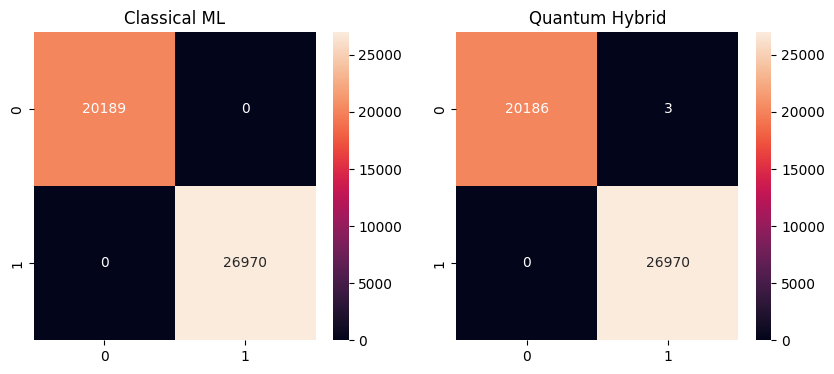

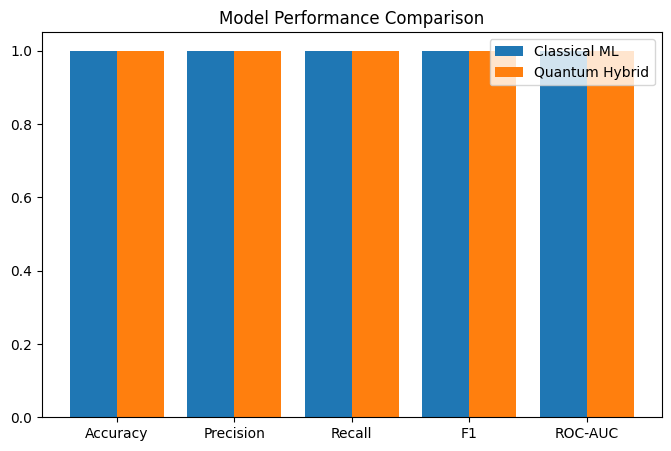

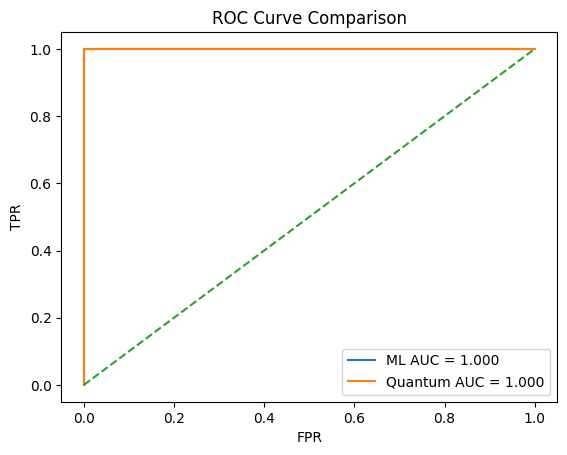

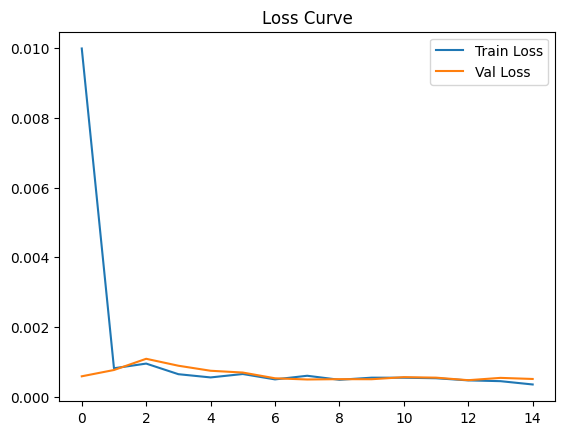

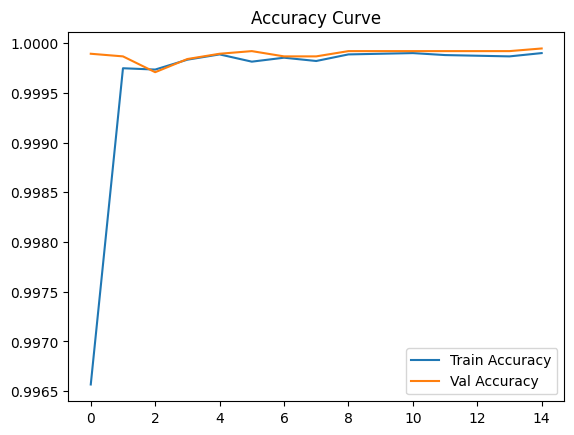

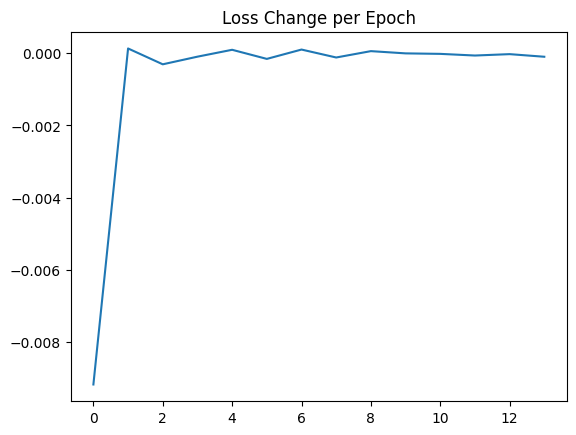

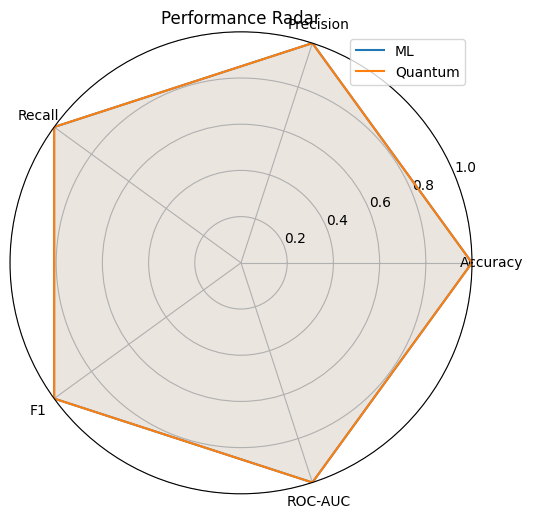

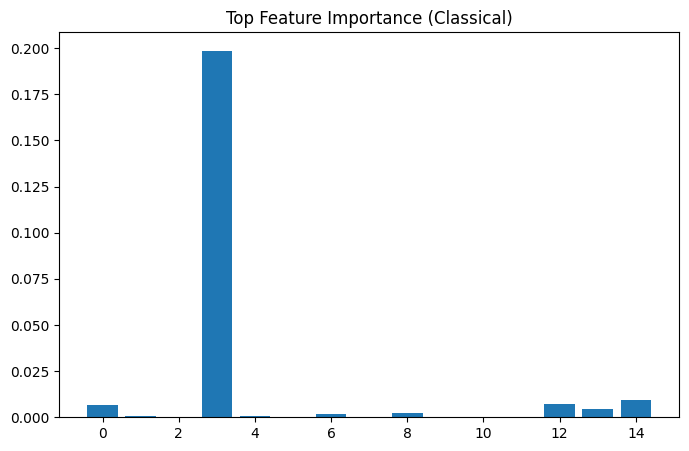

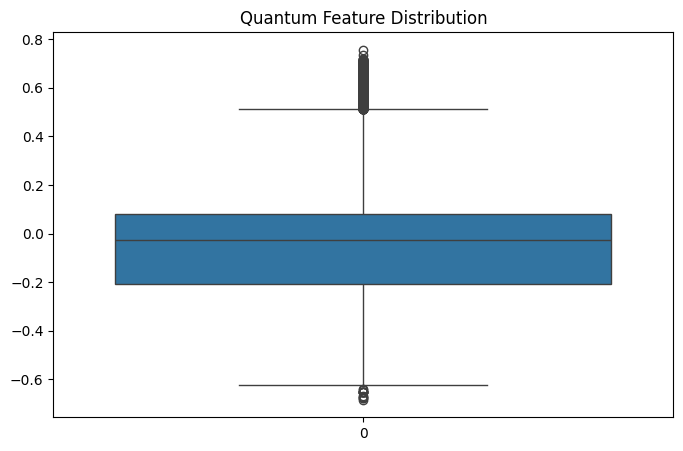


Saved Files:
phishing_model.h5
quantum_model.pkl
scaler.pkl

ALL DONE ✅ — Full Comparison Completed


In [ ]:
# =====================================================
# INSTALL LIBRARIES
# =====================================================
!pip install ucimlrepo qiskit qiskit-machine-learning qiskit-algorithms tensorflow scikit-learn joblib seaborn torch

# =====================================================
# IMPORTS
# =====================================================
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Quantum
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================
# LOAD DATASET
# =====================================================
dataset = fetch_ucirepo(id=967)

X = dataset.data.features
y = dataset.data.targets.iloc[:, 0]

X = X.select_dtypes(include=[np.number])
X = X.fillna(X.mean())

print("Dataset Shape:", X.shape)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# SCALING
# =====================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

# =====================================================
# QUANTUM FEATURE NETWORK
# =====================================================
print("\nBuilding Quantum Neural Network...")

num_qubits = 4
subset_size = 300

X_q = X_train_scaled[:subset_size, :num_qubits]
y_q = y_train[:subset_size].values.reshape(-1, 1)

q_scaler = MinMaxScaler()
X_q = q_scaler.fit_transform(X_q)

feature_map = ZZFeatureMap(num_qubits)
ansatz = RealAmplitudes(num_qubits)

qc = feature_map.compose(ansatz)

qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters
)

model_q = TorchConnector(qnn)

optimizer = optim.Adam(model_q.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

X_tensor = torch.tensor(X_q, dtype=torch.float32)
y_tensor = torch.tensor(y_q, dtype=torch.float32)

for epoch in range(20):
    optimizer.zero_grad()
    output = model_q(X_tensor)
    loss = loss_fn(output, y_tensor)
    loss.backward()
    optimizer.step()

print("Quantum Training Done")

# =====================================================
# QUANTUM FEATURE GENERATOR
# =====================================================
def quantum_features(X_data):
    X_small = X_data[:, :num_qubits]
    X_small = q_scaler.transform(X_small)
    X_tensor = torch.tensor(X_small, dtype=torch.float32)
    with torch.no_grad():
        q_out = model_q(X_tensor).numpy()
    return q_out

X_train_q = quantum_features(X_train_scaled)
X_test_q = quantum_features(X_test_scaled)

X_train_final = np.hstack([X_train_scaled, X_train_q])
X_test_final = np.hstack([X_test_scaled, X_test_q])

print("Final Feature Shape:", X_train_final.shape)

# =====================================================
# DEEP LEARNING MODEL
# =====================================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_final.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Quantum Hybrid Deep Learning Model...")

history = model.fit(
    X_train_final,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# =====================================================
# CLASSICAL ML MODEL
# =====================================================
print("\nTraining Classical ML Model...")

ml_model = RandomForestClassifier(n_estimators=150, random_state=42)
ml_model.fit(X_train_scaled, y_train)

ml_preds = ml_model.predict(X_test_scaled)
ml_probs = ml_model.predict_proba(X_test_scaled)[:, 1]

# =====================================================
# HYBRID MODEL EVALUATION
# =====================================================
dl_probs = model.predict(X_test_final).flatten()
dl_preds = (dl_probs > 0.5).astype(int)

def get_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

ml_metrics = get_metrics(y_test, ml_preds, ml_probs)
dl_metrics = get_metrics(y_test, dl_preds, dl_probs)

print("\nClassical ML Metrics:", ml_metrics)
print("Quantum Hybrid Metrics:", dl_metrics)

# =====================================================
# CONFUSION MATRICES
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(confusion_matrix(y_test, ml_preds), annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Classical ML")

sns.heatmap(confusion_matrix(y_test, dl_preds), annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Quantum Hybrid")

plt.show()

# =====================================================
# BAR COMPARISON
# =====================================================
labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

ml_values = list(ml_metrics.values())
dl_values = list(dl_metrics.values())

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, ml_values, width=0.4, label="Classical ML")
plt.bar(x + 0.2, dl_values, width=0.4, label="Quantum Hybrid")
plt.xticks(x, labels)
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

# =====================================================
# ROC CURVE COMPARISON
# =====================================================
ml_fpr, ml_tpr, _ = roc_curve(y_test, ml_probs)
dl_fpr, dl_tpr, _ = roc_curve(y_test, dl_probs)

plt.figure()
plt.plot(ml_fpr, ml_tpr, label=f"ML AUC = {ml_metrics['roc_auc']:.3f}")
plt.plot(dl_fpr, dl_tpr, label=f"Quantum AUC = {dl_metrics['roc_auc']:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =====================================================
# TRAINING CURVES
# =====================================================
plt.figure()
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# =====================================================
# LOSS CHANGE RATE
# =====================================================
loss_change = np.diff(history.history['loss'])

plt.figure()
plt.plot(loss_change)
plt.title("Loss Change per Epoch")
plt.show()

# =====================================================
# RADAR CHART
# =====================================================
categories = labels
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)

ml_vals = ml_values + [ml_values[0]]
dl_vals = dl_values + [dl_values[0]]
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, ml_vals, label="ML")
ax.plot(angles, dl_vals, label="Quantum")

ax.fill(angles, ml_vals, alpha=0.1)
ax.fill(angles, dl_vals, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.legend()
plt.title("Performance Radar")
plt.show()

# =====================================================
# FEATURE IMPORTANCE
# =====================================================
importances = ml_model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(range(len(importances[:15])), importances[:15])
plt.title("Top Feature Importance (Classical)")
plt.show()

# =====================================================
# QUANTUM FEATURE DISTRIBUTION
# =====================================================
plt.figure(figsize=(8,5))
sns.boxplot(data=X_train_q)
plt.title("Quantum Feature Distribution")
plt.show()

# =====================================================
# SAVE MODELS
# =====================================================
model.save("phishing_model.h5")
joblib.dump(model_q, "quantum_model.pkl")

print("\nSaved Files:")
print("phishing_model.h5")
print("quantum_model.pkl")
print("scaler.pkl")

print("\nALL DONE ✅ — Full Comparison Completed")

Dataset Shape: (235795, 50)



Building Quantum Neural Network...
Quantum Training Done
Final Feature Shape: (188636, 51)

Training Hybrid Model...
Epoch 1/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9971 - loss: 0.0089 - val_accuracy: 0.9999 - val_loss: 5.3774e-04
Epoch 2/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9998 - loss: 8.3312e-04 - val_accuracy: 0.9998 - val_loss: 7.7393e-04
Epoch 3/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9998 - loss: 8.0664e-04 - val_accuracy: 0.9999 - val_loss: 4.6443e-04
Epoch 4/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9999 - loss: 6.8075e-04 - val_accuracy: 0.9998 - val_loss: 5.9738e-04
Epoch 5/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9999 - loss: 6.0945e-04 - val_accuracy: 0.9999 - val_loss: 3.4888e-04
Epoch 6/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9998 - loss: 7.8925e-04 - val_accuracy: 0.9998 - val_loss: 5.0979e-04
Epoch 7/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - a

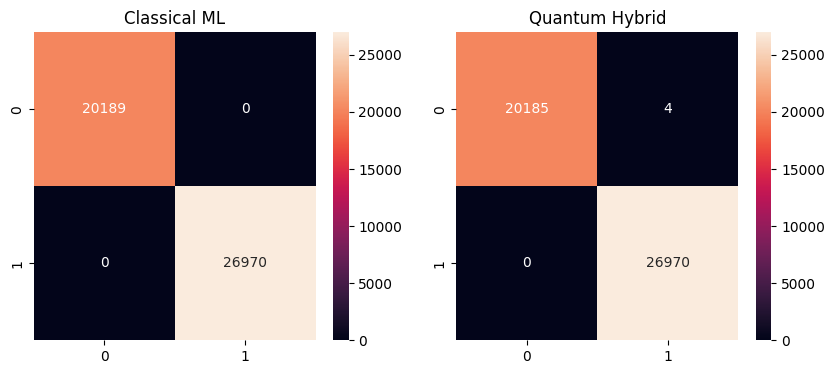

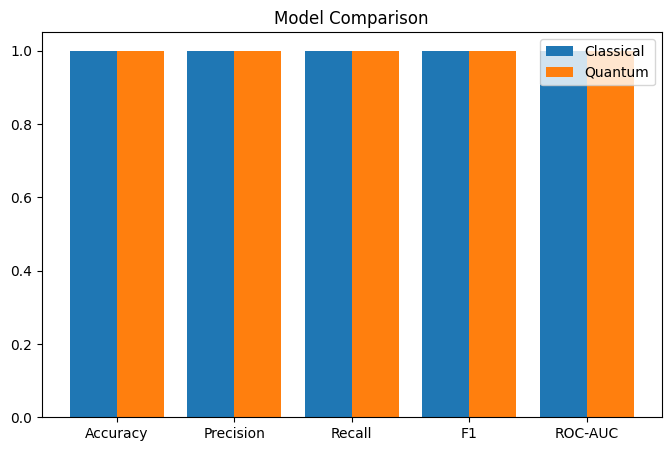

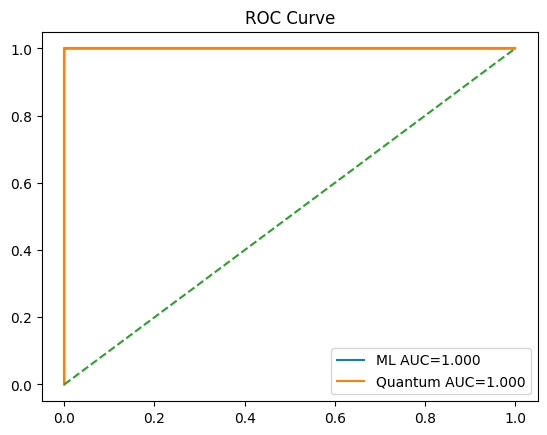

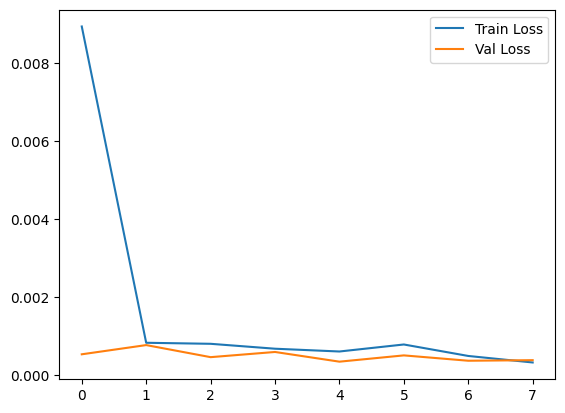

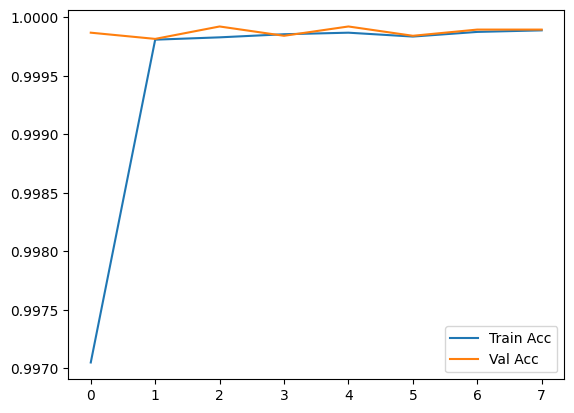

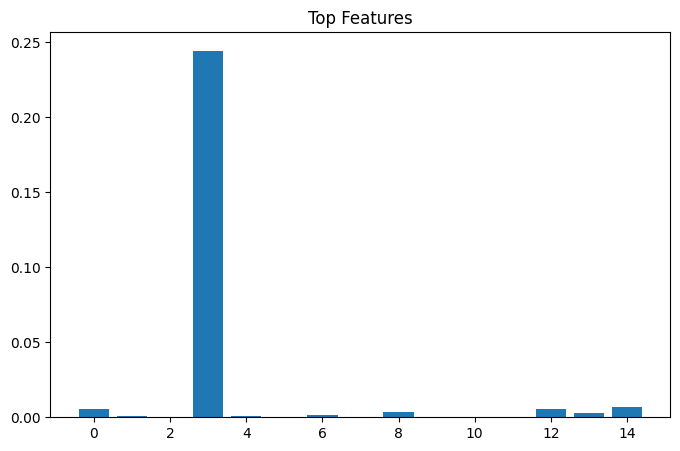

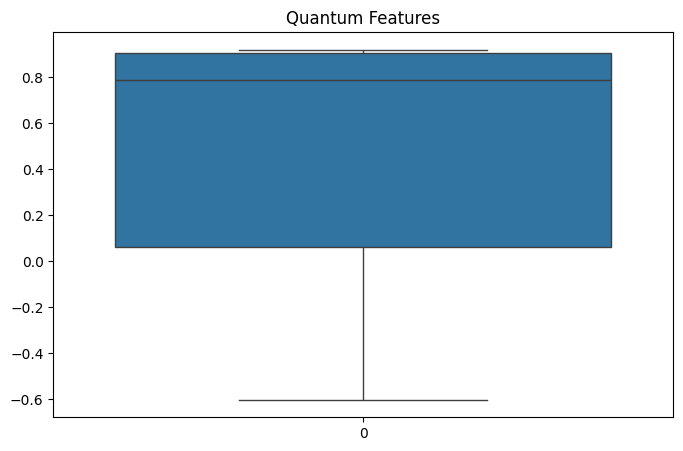


ALL DONE ✅


In [ ]:
# =====================================================
# INSTALL LIBRARIES
# =====================================================
!pip install ucimlrepo qiskit qiskit-machine-learning qiskit-algorithms tensorflow scikit-learn joblib seaborn torch

# =====================================================
# IMPORTS
# =====================================================
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

# Quantum
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================
# LOAD DATASET
# =====================================================
dataset = fetch_ucirepo(id=967)

X = dataset.data.features
y = dataset.data.targets.iloc[:, 0]

X = X.select_dtypes(include=[np.number])
X = X.loc[:, X.nunique() > 1]  # remove constant cols
X = X.fillna(X.mean())

print("Dataset Shape:", X.shape)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# SCALING
# =====================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

# =====================================================
# QUANTUM MODEL
# =====================================================
print("\nBuilding Quantum Neural Network...")

num_qubits = 4
subset_size = 2000

X_q = X_train_scaled[:subset_size, :num_qubits]
y_q = y_train[:subset_size].values.reshape(-1, 1)

q_scaler = MinMaxScaler()
X_q = q_scaler.fit_transform(X_q)

feature_map = zz_feature_map(num_qubits)
ansatz = real_amplitudes(num_qubits)

qc = feature_map.compose(ansatz)

qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters
)

model_q = TorchConnector(qnn)

optimizer = optim.Adam(model_q.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

X_tensor = torch.tensor(X_q, dtype=torch.float32)
y_tensor = torch.tensor(y_q, dtype=torch.float32)

for epoch in range(10):
    for i in range(0, len(X_tensor), 64):
        xb = X_tensor[i:i+64]
        yb = y_tensor[i:i+64]

        optimizer.zero_grad()
        output = model_q(xb)
        loss = loss_fn(output, yb)
        loss.backward()
        optimizer.step()

print("Quantum Training Done")

# =====================================================
# QUANTUM FEATURES
# =====================================================
def quantum_features(X_data):
    X_small = X_data[:, :num_qubits]
    X_small = q_scaler.transform(X_small)
    X_tensor = torch.tensor(X_small, dtype=torch.float32)
    with torch.no_grad():
        return model_q(X_tensor).numpy()

X_train_q = quantum_features(X_train_scaled)
X_test_q = quantum_features(X_test_scaled)

X_train_final = np.hstack([X_train_scaled, X_train_q])
X_test_final = np.hstack([X_test_scaled, X_test_q])

print("Final Feature Shape:", X_train_final.shape)

# =====================================================
# DEEP LEARNING MODEL
# =====================================================
model = Sequential([
    Input(shape=(X_train_final.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(patience=3, restore_best_weights=True)

print("\nTraining Hybrid Model...")

history = model.fit(
    X_train_final,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# =====================================================
# CLASSICAL MODEL
# =====================================================
print("\nTraining Classical Model...")

ml_model = RandomForestClassifier(n_estimators=100, max_depth=15)
ml_model.fit(X_train_scaled, y_train)

ml_preds = ml_model.predict(X_test_scaled)
ml_probs = ml_model.predict_proba(X_test_scaled)[:, 1]

# =====================================================
# HYBRID EVALUATION
# =====================================================
dl_probs = model.predict(X_test_final).flatten()
dl_preds = (dl_probs > 0.5).astype(int)

def get_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

ml_metrics = get_metrics(y_test, ml_preds, ml_probs)
dl_metrics = get_metrics(y_test, dl_preds, dl_probs)

print("\nClassical ML Metrics:", ml_metrics)
print("Quantum Hybrid Metrics:", dl_metrics)

# =====================================================
# CONFUSION MATRIX
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(confusion_matrix(y_test, ml_preds), annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Classical ML")

sns.heatmap(confusion_matrix(y_test, dl_preds), annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Quantum Hybrid")

plt.show()

# =====================================================
# BAR CHART
# =====================================================
labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
ml_values = list(ml_metrics.values())
dl_values = list(dl_metrics.values())

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, ml_values, width=0.4, label="Classical")
plt.bar(x + 0.2, dl_values, width=0.4, label="Quantum")
plt.xticks(x, labels)
plt.legend()
plt.title("Model Comparison")
plt.show()

# =====================================================
# ROC CURVE
# =====================================================
ml_fpr, ml_tpr, _ = roc_curve(y_test, ml_probs)
dl_fpr, dl_tpr, _ = roc_curve(y_test, dl_probs)

plt.figure()
plt.plot(ml_fpr, ml_tpr, label=f"ML AUC={ml_metrics['roc_auc']:.3f}")
plt.plot(dl_fpr, dl_tpr, label=f"Quantum AUC={dl_metrics['roc_auc']:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# =====================================================
# TRAINING CURVES
# =====================================================
plt.figure()
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.show()

# =====================================================
# FEATURE IMPORTANCE
# =====================================================
plt.figure(figsize=(8,5))
plt.bar(range(15), ml_model.feature_importances_[:15])
plt.title("Top Features")
plt.show()

# =====================================================
# QUANTUM FEATURE DISTRIBUTION
# =====================================================
plt.figure(figsize=(8,5))
sns.boxplot(data=X_train_q)
plt.title("Quantum Features")
plt.show()

# =====================================================
# SAVE MODELS
# =====================================================
model.save("phishing_model.h5")
joblib.dump(model_q, "quantum_model.pkl")

print("\nALL DONE ✅")